In [39]:
## importing Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [40]:
df = pd.read_csv('economic_index.csv')

In [41]:
df.head()

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256


In [42]:
df.drop(["Unnamed: 0","year","month"],axis=1,inplace=True)

In [43]:
df

,interest_rate,unemployment_rate,index_price
0,2.75,5.3,1464
1,2.50,5.3,1394
2,2.50,5.3,1357
3,2.50,5.3,1293
4,2.50,5.4,1256
5,2.50,5.6,1254
6,2.50,5.5,1234
7,2.25,5.5,1195
8,2.25,5.5,1159
9,2.25,5.6,1167


In [44]:
df.isnull().sum()

interest_rate        0
unemployment_rate    0
index_price          0
dtype: int64

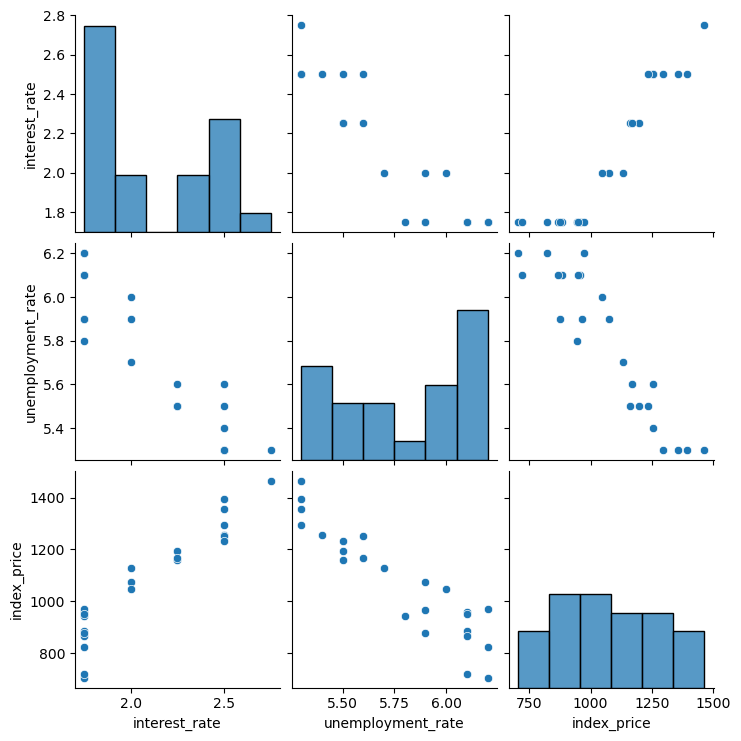

In [45]:
sns.pairplot(df) ## to see the relation

In [46]:
df.corr()

,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,-0.925814,0.935793
unemployment_rate,-0.925814,1.000000,-0.922338
index_price,0.935793,-0.922338,1.000000


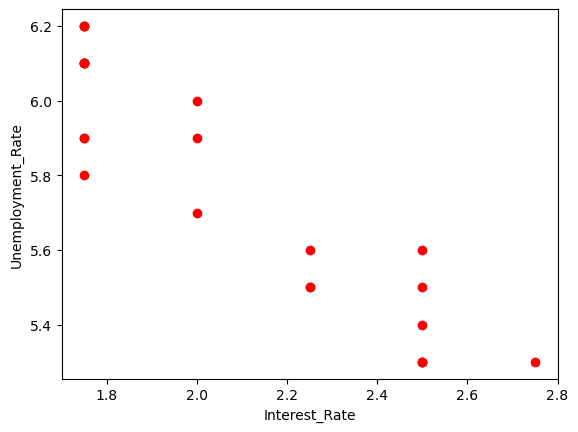

<Figure size 640x480 with 0 Axes>

In [49]:
plt.scatter(df['interest_rate'],df['unemployment_rate'],color='red')
plt.xlabel('Interest_Rate')
plt.ylabel('Unemployment_Rate')
plt.show() 
plt.tight_layout()

In [50]:
## independent and dependent 
#X = df[['interest_rate','unemployment_rate']]
#y = df['index_price']

## Or

X=df.iloc[:,:-1]
y=df.iloc[:,-1]

In [60]:
X

,interest_rate,unemployment_rate
0,2.75,5.3
1,2.50,5.3
2,2.50,5.3
3,2.50,5.3
4,2.50,5.4
5,2.50,5.6
6,2.50,5.5
7,2.25,5.5
8,2.25,5.5
9,2.25,5.6


In [52]:
y

0     1464
1     1394
2     1357
3     1293
4     1256
5     1254
6     1234
7     1195
8     1159
9     1167
10    1130
11    1075
12    1047
13     965
14     943
15     958
16     971
17     949
18     884
19     866
20     876
21     822
22     704
23     719
Name: index_price, dtype: int64

In [53]:
## train test split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=42)

In [54]:
X_train.shape

(18, 2)

In [55]:
y_train.shape

(18,)

In [56]:
X_test.shape

(6, 2)

<Axes: xlabel='interest_rate', ylabel='index_price'>

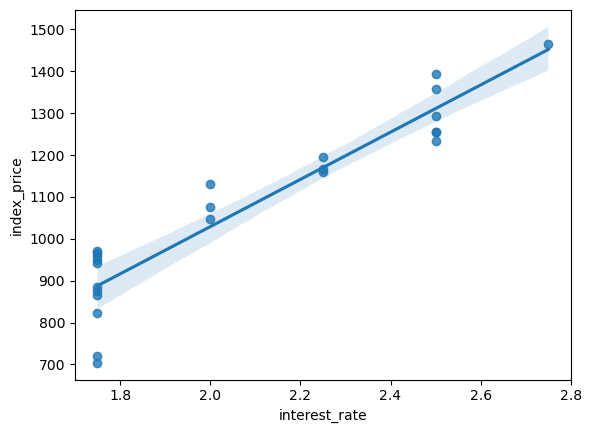

In [62]:
sns.regplot(x=df['interest_rate'],y=df['index_price'],data=df)


<Axes: xlabel='interest_rate', ylabel='unemployment_rate'>

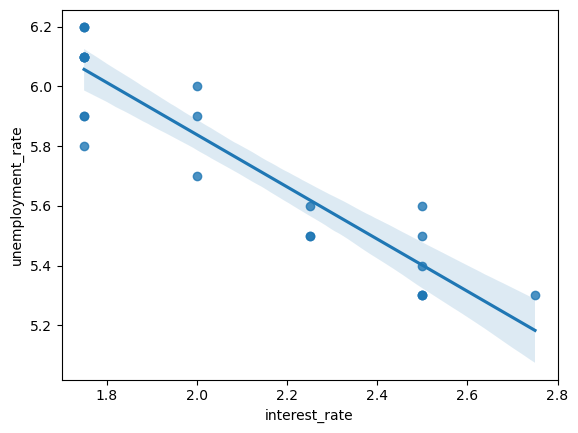

In [63]:
sns.regplot(x=df['interest_rate'],y=df['unemployment_rate'],data=df)

In [64]:
## Standardization
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [65]:
X_train = scaler.fit_transform(X_train)

In [66]:
X_test = scaler.transform(X_test)

In [67]:
X_train


array([[-0.90115511,  0.37908503],
       [ 1.31077107, -1.48187786],
       [-0.90115511,  1.30956648],
       [ 1.31077107, -0.55139641],
       [ 1.31077107, -1.48187786],
       [-0.16384638,  0.68924552],
       [-0.90115511,  0.999406  ],
       [ 1.31077107, -1.48187786],
       [ 1.31077107, -1.17171738],
       [-0.90115511,  1.30956648],
       [-0.90115511,  0.999406  ],
       [-0.90115511,  0.37908503],
       [-0.90115511,  0.999406  ],
       [ 0.57346234, -0.8615569 ],
       [-0.16384638, -0.24123593],
       [-0.90115511,  0.06892455],
       [-0.90115511,  0.999406  ],
       [ 1.31077107, -0.8615569 ]])

In [68]:
X_test

array([[ 0.57346234, -0.8615569 ],
       [-0.90115511,  1.30956648],
       [ 2.0480798 , -1.48187786],
       [-0.90115511,  0.999406  ],
       [-0.16384638,  0.37908503],
       [ 0.57346234, -0.55139641]])

In [ ]:
## applying linear regression

In [69]:
from sklearn.linear_model import LinearRegression

In [70]:
model = LinearRegression(n_jobs=-1)

In [73]:
m_regression = model.fit(X_train,y_train)

In [74]:
y_pred = m_regression.predict(X_test)

In [75]:
y_pred

array([1204.22770398,  821.65051903, 1406.51300368,  857.70889608,
        994.90992298, 1168.16932693])

In [76]:
y_test

8     1159
16     971
0     1464
18     884
11    1075
9     1167
Name: index_price, dtype: int64

In [77]:
regression.coef_

array([  88.27275507, -116.25716066])

In [78]:
regression.intercept_

np.float64(1053.4444444444443)

In [81]:
from sklearn.model_selection import cross_val_score


In [82]:
validation_score = cross_val_score(regression,X_train,y_train,scoring='neg_mean_squared_error',cv=3)

In [84]:
np.mean(validation_score)


np.float64(-5914.828180162396)

In [87]:
## Performance Metrics
from sklearn.metrics import mean_absolute_error,mean_squared_error

In [88]:
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
rmse = np.sqrt(mse)

In [90]:
print(mae,mse,rmse)

59.93578152323558 5793.762887712583 76.11677139574815


In [91]:
from sklearn.metrics import r2_score


In [92]:
score = r2_score(y_test,y_pred)

In [93]:
score

0.8278978091457141

In [97]:
## Adjusted r square
ars = 1 - (1-score)*(len(y_test)-1)/(len(y_test)-X.shape[-1]-1)

In [98]:
ars

0.7131630152428567

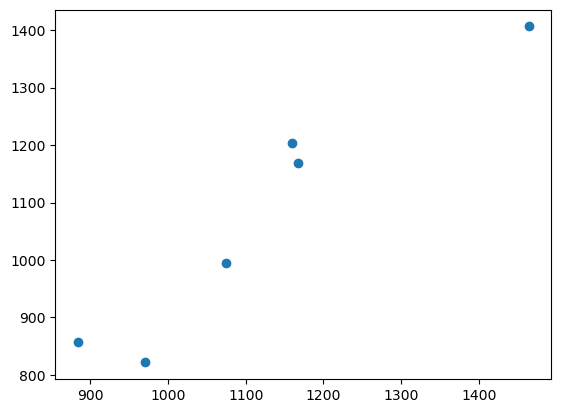

In [101]:
plt.scatter(y_test,y_pred)

In [99]:
residual = y_test-y_pred

In [102]:
residual

8     -45.227704
16    149.349481
0      57.486996
18     26.291104
11     80.090077
9      -1.169327
Name: index_price, dtype: float64

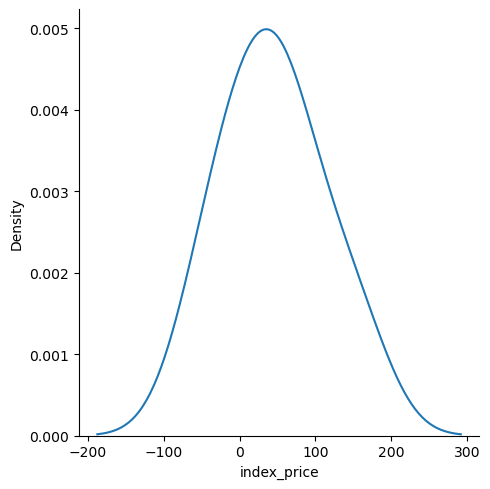

In [100]:
## Assumption
sns.displot(residual,kind='kde')

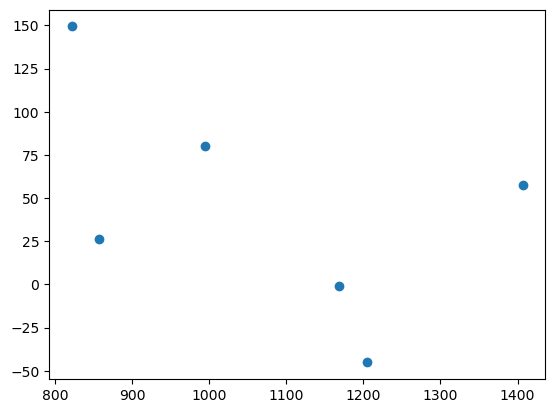

In [103]:
plt.scatter(y_pred,residual)

In [104]:
regression.predict(scaler.transform([[2,7]]))

D:\Shourya Data Analyst\Anaconda\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([598.26777542])

In [105]:
import statsmodels.api as sm

In [108]:
model = sm.OLS(y_train,X_train).fit()

In [110]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:            index_price   R-squared (uncentered):                   0.035
Model:                            OLS   Adj. R-squared (uncentered):             -0.086
Method:                 Least Squares   F-statistic:                             0.2880
Date:                Thu, 30 Jul 2026   Prob (F-statistic):                       0.754
Time:                        14:59:52   Log-Likelihood:                         -150.85
No. Observations:                  18   AIC:                                      305.7
Df Residuals:                      16   BIC:                                      307.5
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1            88.2728    658.295      0.134      0.895   -1307.250    1483.796
x2          -116.2572    658.295     -0.177      0.862   -1511.780    1279.266
==============================================================================
Omnibus:                        0.598   Durbin-Watson:                   0.007
Prob(Omnibus):                  0.741   Jarque-Bera (JB):                0.567
Skew:                          -0.361   Prob(JB):                        0.753
Kurtosis:                       2.517   Cond. No.                         4.78
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [111]:
model.predict(X_test)

array([ 150.78325954, -231.79392541,  353.06855924, -195.73554836,
        -58.53452146,  114.72488249])